Dataset: 768 samples, 8 features
Features: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
Target (Heating Load): mean=22.31, std=10.08

Interval Statistics:
                y     y_lower     y_upper       Delta
count  768.000000  768.000000  768.000000  768.000000
mean    22.307201   21.514501   23.099900    0.792700
std     10.090196   10.129895   10.086770    0.605639
min      6.010000    4.532232    6.161850    0.005156
25%     12.992500   12.406726   14.130242    0.313767
50%     18.950000   18.318929   19.515523    0.667494
75%     31.667500   30.718475   32.557092    1.134260
max     43.100000   42.763548   44.129025    3.884950
Mean interval width: 1.59

Train/Test Split:
  Train: 576 samples
  Test:  192 samples

Scaled data range: [0, 1]

Training neural network...
Epoch 200: Train=0.006397, Val=0.007839, Best Val=0.007839, LR=0.003000
Epoch 400: Train=0.005376, Val=0.006373, Best Val=0.006373, LR=0.003000
Epoch 600: Train=0.005163, Val=0.005998, Best Val=0.005998, LR=0.0030

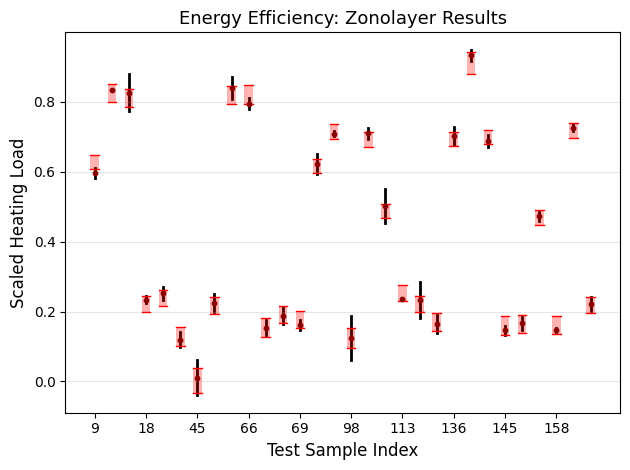

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from zonolayer import Zonolayer


energy_efficiency = fetch_ucirepo(id=242) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets

# Use Heating Load as target
y_heating = y['Y1'].values  # Heating Load

print(f"Dataset: {len(X)} samples, {X.shape[1]} features")
print(f"Features: {list(X.columns)}")
print(f"Target (Heating Load): mean={y_heating.mean():.2f}, std={y_heating.std():.2f}")


def intervalise_heating_load(y, noise_factor=0.1):

    n = len(y)
    

    Delta = np.abs(np.random.normal(loc=0, scale=noise_factor * np.std(y), size=n))
    
    y_lower = y - Delta
    y_upper = y + Delta
    
    return pd.DataFrame({
        "y": y,
        "y_lower": y_lower,
        "y_upper": y_upper,
        "Delta": Delta,
    })

np.random.seed(42)
torch.manual_seed(42)

intervals = intervalise_heating_load(y_heating, noise_factor=0.1)

print("\nInterval Statistics:")
print(intervals.describe())
print(f"Mean interval width: {(intervals['y_upper'] - intervals['y_lower']).mean():.2f}")

X_train, X_test, y_train, y_test, y_lower_train, y_lower_test, y_upper_train, y_upper_test = train_test_split(
    X.values, 
    intervals['y'].values, 
    intervals['y_lower'].values, 
    intervals['y_upper'].values, 
    test_size=0.25, 
    random_state=42
)

print(f"\nTrain/Test Split:")
print(f"  Train: {len(X_train)} samples")
print(f"  Test:  {len(X_test)} samples")

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale y values and intervals
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
y_lower_train_scaled = scaler_y.transform(y_lower_train.reshape(-1, 1)).flatten()
y_lower_test_scaled = scaler_y.transform(y_lower_test.reshape(-1, 1)).flatten()
y_upper_train_scaled = scaler_y.transform(y_upper_train.reshape(-1, 1)).flatten()
y_upper_test_scaled = scaler_y.transform(y_upper_test.reshape(-1, 1)).flatten()

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t = torch.FloatTensor(X_test_scaled)
y_train_t = torch.FloatTensor(y_train_scaled).reshape(-1, 1)
y_test_t = torch.FloatTensor(y_test_scaled).reshape(-1, 1)

print("\nScaled data range: [0, 1]")

class CentreNet(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_centre_net(X_train_t, y_train_t, X_val_t, y_val_t, epochs=5000):
    """Train with proper learning rate management."""
    net = CentreNet(input_dim=8)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=0.003) 

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=300,
        min_lr=1e-6,
    )
    
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    early_stop_patience = 1000
    
    for epoch in range(epochs):
        net.train()
        optimizer.zero_grad()
        pred = net(X_train_t)
        loss = criterion(pred, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer.step()
        
        net.eval()
        with torch.no_grad():
            val_pred = net(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = net.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1} - no improvement for {early_stop_patience} epochs")
            break
        
        if (epoch + 1) % 200 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}: Train={loss.item():.6f}, Val={val_loss:.6f}, Best Val={best_val_loss:.6f}, LR={current_lr:.6f}")
    
    net.load_state_dict(best_state)
    print(f"\nBest validation loss: {best_val_loss:.6f}")
    return net


X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_t, y_train_t, test_size=0.2, random_state=42
)

print("\nTraining neural network...")
centre_net = train_centre_net(X_train_nn, y_train_nn, X_val_nn, y_val_nn, epochs=7000)

# Evaluate NN
centre_net.eval()
with torch.no_grad():
    train_pred = centre_net(X_train_t).numpy().flatten()
    test_pred = centre_net(X_test_t).numpy().flatten()
    
    train_mse = np.mean((train_pred - y_train_scaled)**2)
    test_mse = np.mean((test_pred - y_test_scaled)**2)
    test_mae = np.mean(np.abs(test_pred - y_test_scaled))

print(f"\n=== Neural Network Results (Scaled) ===")
print(f"Train RMSE: {np.sqrt(train_mse):.6f}")
print(f"Test RMSE:  {np.sqrt(test_mse):.6f}")
print(f"Test MAE:   {test_mae:.6f}")



zl = Zonolayer(centre_net, lambda_reg=1e-3)
results = zl.compute(
    x_train=X_train_t,
    x_test=X_test_t,
    y_lower=y_lower_train_scaled,
    y_upper=y_upper_train_scaled,
)

y_centre_pred = results["pred_centre"]
y_lower_zono = results["y_lower_pred"]
y_upper_zono = results["y_upper_pred"]



np.random.seed(42)
n_plot = 30
plot_indices = np.random.choice(len(y_test_scaled), n_plot, replace=False)
plot_indices = np.sort(plot_indices)

fig, ax = plt.subplots()

x_pos = np.arange(n_plot)
bar_width = 0.5

# Plot true intervals (black)
for i, idx in enumerate(plot_indices):
    ax.plot([x_pos[i], x_pos[i]], 
            [y_lower_test_scaled[idx], y_upper_test_scaled[idx]],
            color='black', linewidth=2, zorder=1,
            label='True Interval' if i == 0 else '')
    ax.scatter(x_pos[i], y_test_scaled[idx], 
               color='darkred', s=10, zorder=5,
               label='True Center' if i == 0 else '')

# Plot zonotope intervals (red bars)
for i, idx in enumerate(plot_indices):
    ax.fill_between([x_pos[i] - bar_width/2, x_pos[i] + bar_width/2],
                     [y_lower_zono[idx], y_lower_zono[idx]],
                     [y_upper_zono[idx], y_upper_zono[idx]],
                     color='red', alpha=0.3, linewidth=0, zorder=2,
                     label='Zonotope (INN)' if i == 0 else '')
    ax.plot([x_pos[i] - bar_width/2, x_pos[i] + bar_width/2],
            [y_lower_zono[idx], y_lower_zono[idx]],
            color='red', linewidth=1)
    ax.plot([x_pos[i] - bar_width/2, x_pos[i] + bar_width/2],
            [y_upper_zono[idx], y_upper_zono[idx]],
            color='red', linewidth=1)

# Plot NN predictions
# ax.scatter(x_pos, y_centre_pred[plot_indices], 
#            color='blue', s=40, marker='x', linewidths=2,
#            label='NN Prediction', zorder=4)

ax.set_xlabel('Test Sample Index', fontsize=12)
ax.set_ylabel('Scaled Heating Load', fontsize=12)
ax.set_title(f'Energy Efficiency: Zonolayer Results', fontsize=13)
ax.set_xticks(x_pos[::3])
ax.set_xticklabels(plot_indices[::3])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("energy_efficiency_zonolayer.pdf", bbox_inches="tight")
plt.show()